In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_filtered_features_3lakh.csv')
df.head()

,text,Label,filtered_text_eng,tokenized_text,Preprocessed_Text,filtered_tokenized_words
0,"I'm done with it all. Any tips?First of all, i...",2,done with it Any of if going to comment get or...,"['done', 'go', 'comment', 'get', 'plea', 'unde...",done go comment get plea understand want hear ...,"['kill', 'pain', 'sorri', 'hate']"
1,i 20m was a problem child when grow up i frequ...,1,i was a problem child when grow up i frequent ...,"['problem', 'child', 'grow', 'frequent', 'got'...",problem child grow frequent got troubl junior ...,"['ill', 'awkward', 'steal', 'silenc', 'wrong',..."
2,I officially hate my school We have to start p...,0,I officially hate my school We have to start o...,"['offici', 'hate', 'school', 'start', 'enter',...",offici hate school start enter caus fix,"['offici', 'hate', 'school', 'start', 'enter',..."
3,but onc again depress love to take that from m...,1,but onc again depress love to take that from m...,"['onc', 'depress', 'love', 'take', 'angri', 'w...",onc depress love take angri want cri wont come...,"['cri', 'angri', 'damn', 'tire', 'depress']"
4,"Starting today, I'm going to attempt to fix my...",0,Starting going to attempt to fix my sleep sche...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc...",start go attempt fix sleep schedul school coup...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc..."


In [3]:
df1 = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_all_features.csv')
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,2781,2782,2783,2784,2785,2786,2787,2788,2789,2790
0,-0.311691,0.207526,0.294796,-0.370256,-0.463946,0.004523,0.103642,0.023245,-0.273210,-0.043930,...,1.174970,-0.131030,0.581713,1.317829,0.545300,-4.912285,2.002302,-2.429308,2.313626,0.068317
1,-0.314458,0.200302,0.248307,-0.337924,-0.354438,-0.029178,0.120759,0.028209,-0.381361,-0.010982,...,-0.170022,-1.057125,0.506787,0.481089,-0.443753,-1.015673,0.295432,-1.521313,-0.511028,-0.270724
2,-0.258834,0.199409,0.255281,-0.329083,-0.421285,-0.008494,0.122459,0.000529,-0.345936,-0.007731,...,-0.475023,-2.049421,-2.095686,-2.270150,2.747774,-4.004583,-1.818186,-3.040991,-0.021306,1.718746
3,-0.348873,0.164237,0.313819,-0.395596,-0.340182,-0.008542,0.077583,-0.002947,-0.369009,0.005620,...,1.116820,0.496508,2.048395,-0.856290,0.582634,-1.573221,0.650254,-1.483610,0.080408,-0.893238
4,-0.258569,0.201524,0.242732,-0.321395,-0.432100,-0.044947,0.111697,0.009705,-0.350573,-0.033735,...,-0.861691,-1.552952,-0.070507,-2.612564,0.754670,-5.594344,3.663493,-0.440785,1.437596,-0.616004


In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [5]:
# Apply PCA
pca = PCA(n_components=100, random_state=42)
X = pca.fit_transform(X_scaled)

In [6]:
X.shape

(287398, 100)

In [7]:
y = df['Label'].values

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = True)

AdaBoost training completed in 4.93 minutes
Cross-validated Accuracy (AdaBoost): 0.7766
Classification Report (AdaBoost):
               precision    recall  f1-score   support

           0       0.89      0.90      0.89     19749
           1       0.72      0.75      0.74     19373
           2       0.70      0.66      0.68     18358

    accuracy                           0.77     57480
   macro avg       0.77      0.77      0.77     57480
weighted avg       0.77      0.77      0.77     57480



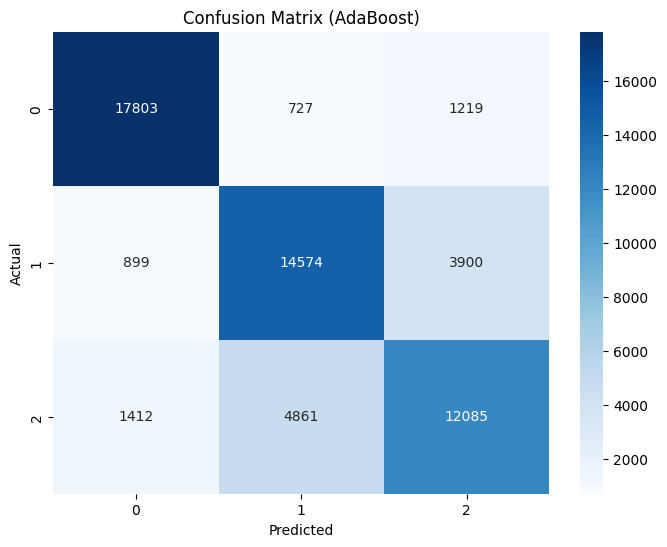

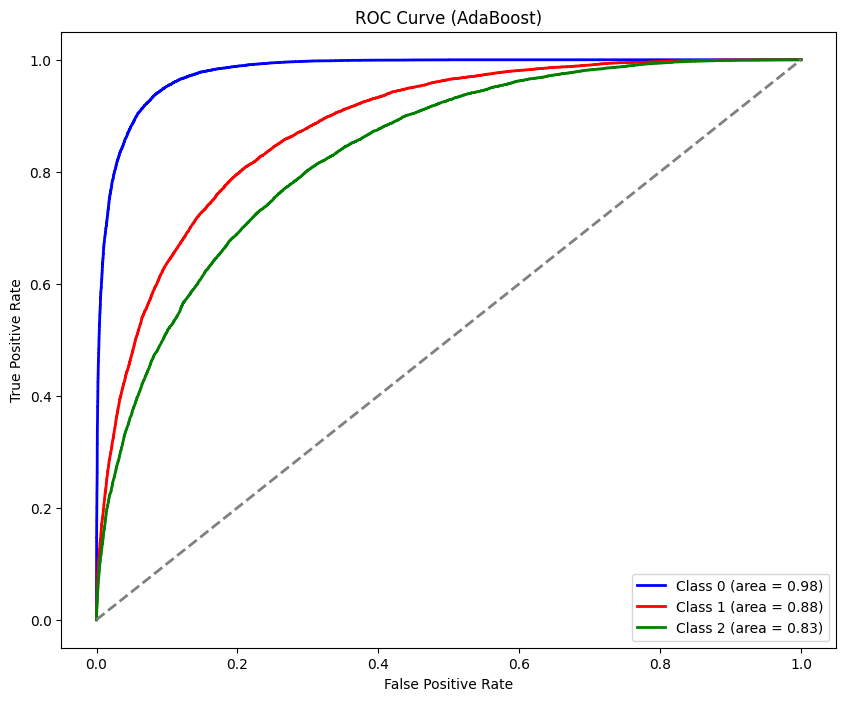

In [9]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train AdaBoost Classifier
ada = AdaBoostClassifier(random_state=42)

# Measure training time
start_time = time.time()
ada.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"AdaBoost training completed in {training_time_minutes:.2f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(ada, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (AdaBoost): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = ada.predict(X_test)
y_prob = ada.predict_proba(X_test)

# Classification Report
print("Classification Report (AdaBoost):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (AdaBoost)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/AdaBoost/Confusion_Mtrix_Best_Adaboost.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AdaBoost)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/AdaBoost/ROC_Curve_Best_Adaboost.png")
plt.show()

Random Forest training completed in 8.81 minutes
Cross-validated Accuracy (Random Forest): 0.8575
Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.91      0.97      0.94     19749
           1       0.85      0.79      0.82     19373
           2       0.80      0.80      0.80     18358

    accuracy                           0.86     57480
   macro avg       0.85      0.85      0.85     57480
weighted avg       0.85      0.86      0.85     57480



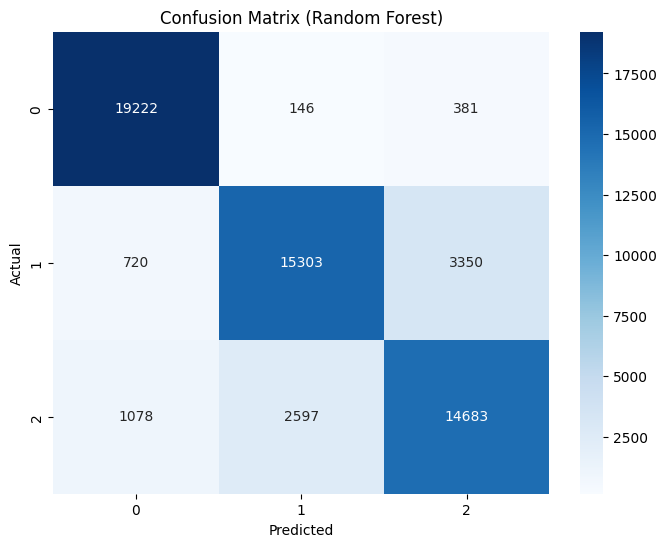

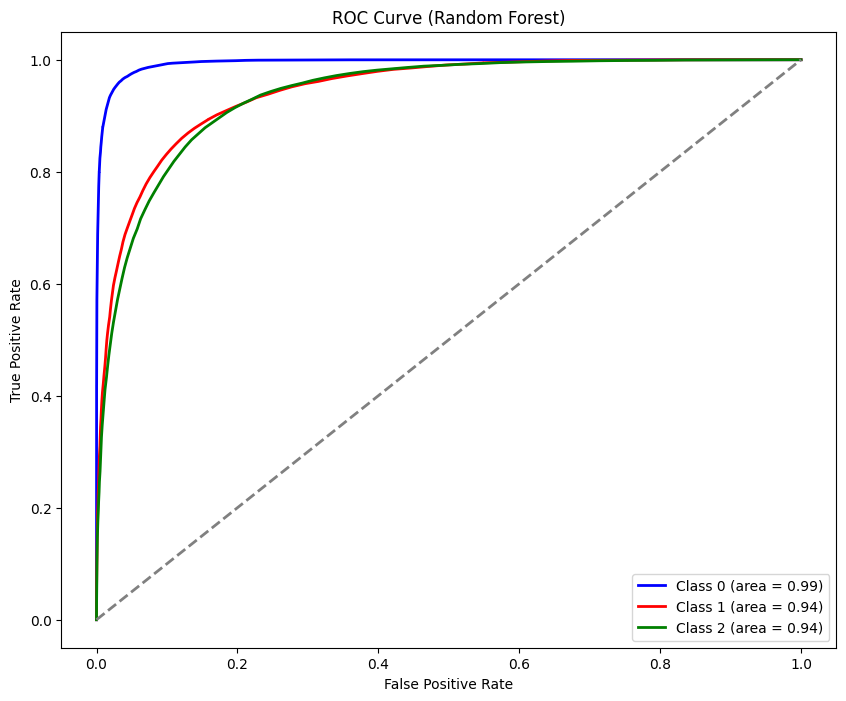

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Measure training time
start_time = time.time()
rf.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"Random Forest training completed in {training_time_minutes:.2f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (Random Forest): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

# Classification Report
print("Classification Report (Random Forest):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Random Forest/Confusion_Mtrix_RF.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Random Forest/ROC_Curve_RF.png")
plt.show()

Gradient Boosting training completed in 76.31 minutes
Cross-validated Accuracy (Gradient Boosting): 0.8670
Classification Report (Gradient Boosting):
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     19749
           1       0.85      0.81      0.83     19373
           2       0.81      0.81      0.81     18358

    accuracy                           0.87     57480
   macro avg       0.86      0.86      0.86     57480
weighted avg       0.86      0.87      0.86     57480



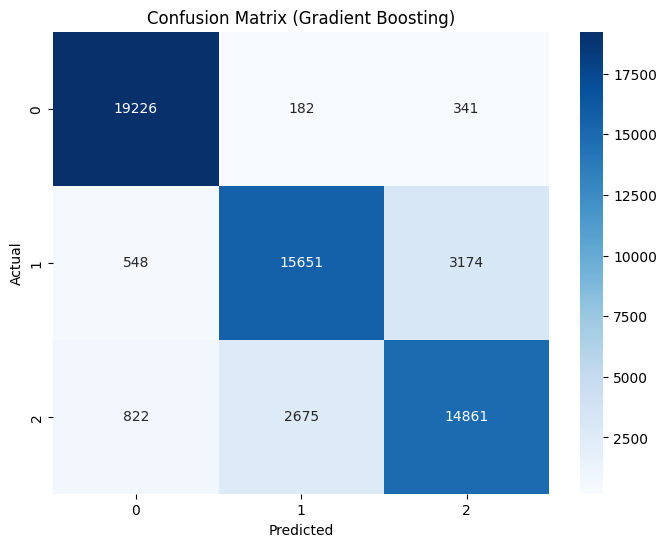

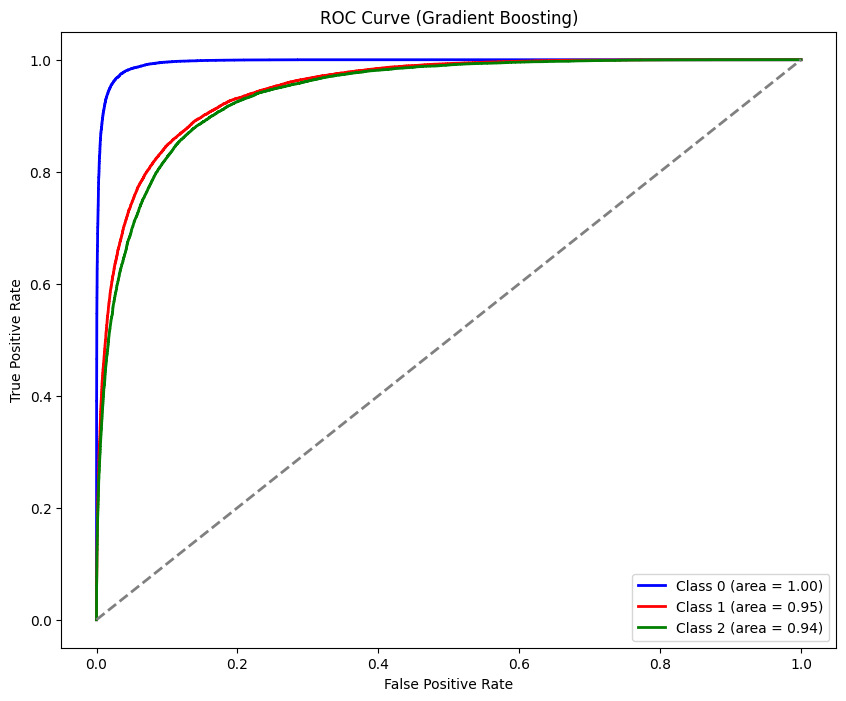

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train Gradient Boosting Classifier
gbm = GradientBoostingClassifier(random_state=42)


# Measure training time
start_time = time.time()
gbm.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"Gradient Boosting training completed in {training_time_minutes:.2f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(gbm, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (Gradient Boosting): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = gbm.predict(X_test)
y_prob = gbm.predict_proba(X_test)

# Classification Report
print("Classification Report (Gradient Boosting):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Gradient Boosting)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Light GBM/Confusion_Mtrix_Gradient_Boosting_Machines.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Gradient Boosting)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Light GBM/ROC_Curve_Gradient_Boosting_Machines.png")
plt.show()

XGBoost training completed in 0.22 minutes
Cross-validated Accuracy (XGBoost): 0.9027
Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     19749
           1       0.87      0.85      0.86     19373
           2       0.85      0.85      0.85     18358

    accuracy                           0.90     57480
   macro avg       0.90      0.90      0.90     57480
weighted avg       0.90      0.90      0.90     57480



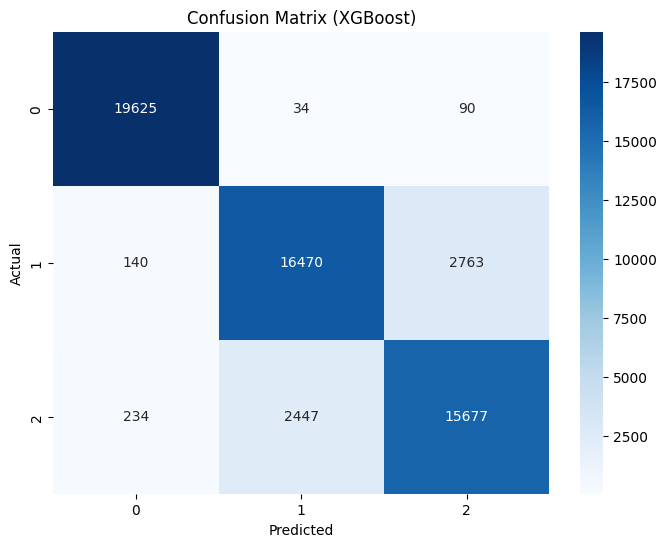

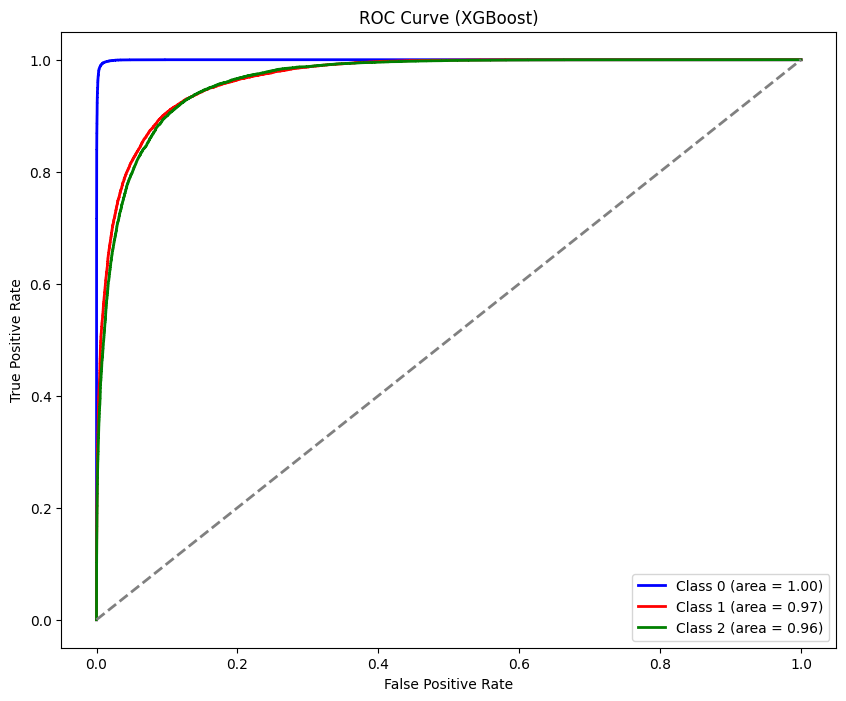

In [12]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train XGBoost Classifier
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

# Measure training time
start_time = time.time()
xgb_model.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"XGBoost training completed in {training_time_minutes:.2f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (XGBoost): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

# Classification Report
print("Classification Report (XGBoost):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/XGBoost/Confusion_Mtrix_XGBoost.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/XGBoost/ROC_Curve_XGBoost.png")
plt.show()

KNN training completed in 0.0008 minutes
Cross-validated Accuracy (KNN): 0.8470
Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.91      0.98      0.95     19749
           1       0.81      0.80      0.81     19373
           2       0.80      0.75      0.77     18358

    accuracy                           0.85     57480
   macro avg       0.84      0.84      0.84     57480
weighted avg       0.84      0.85      0.84     57480



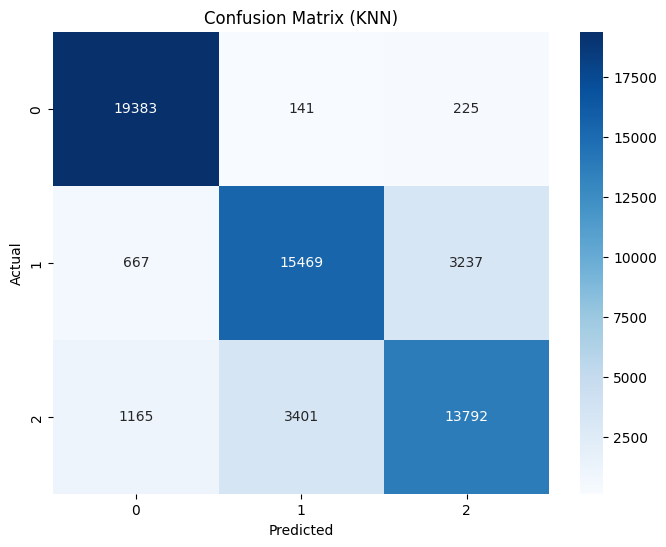

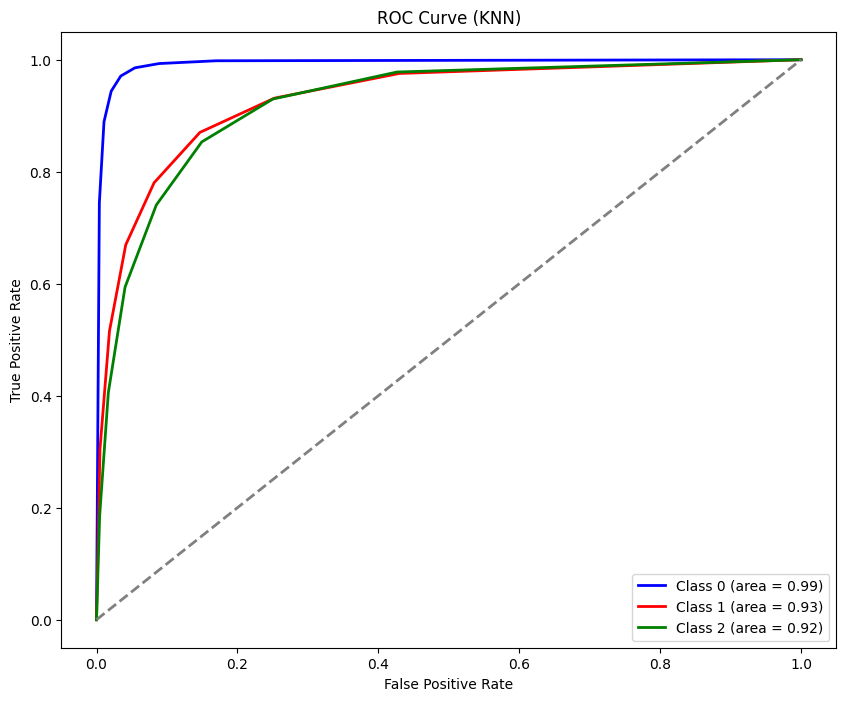

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=7)

start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"KNN training completed in {training_time_minutes:.4f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (KNN): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)

# Classification Report
print("Classification Report (KNN):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (KNN)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/KNN/Confusion_Mtrix_KNN.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (KNN)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/KNN/ROC_Curve_KNN.png")
plt.show()

Naive Bayes training completed in 0.0066 minutes
Cross-validated Accuracy (Naive Bayes): 0.7233
Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.75      0.74      0.74     19749
           1       0.72      0.77      0.74     19373
           2       0.69      0.65      0.67     18358

    accuracy                           0.72     57480
   macro avg       0.72      0.72      0.72     57480
weighted avg       0.72      0.72      0.72     57480



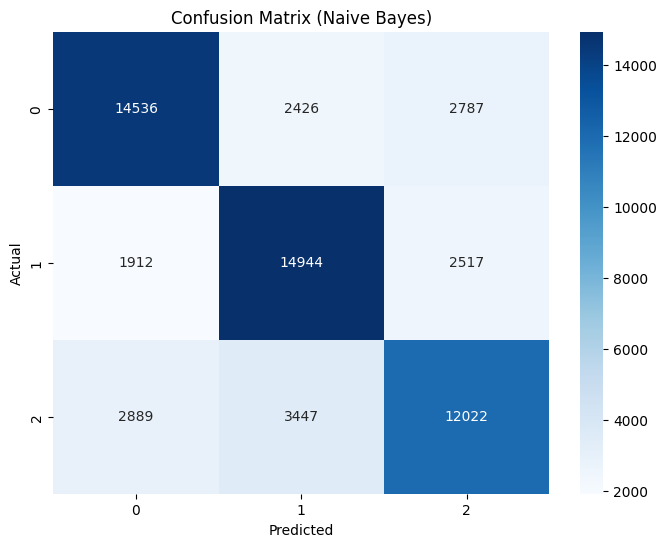

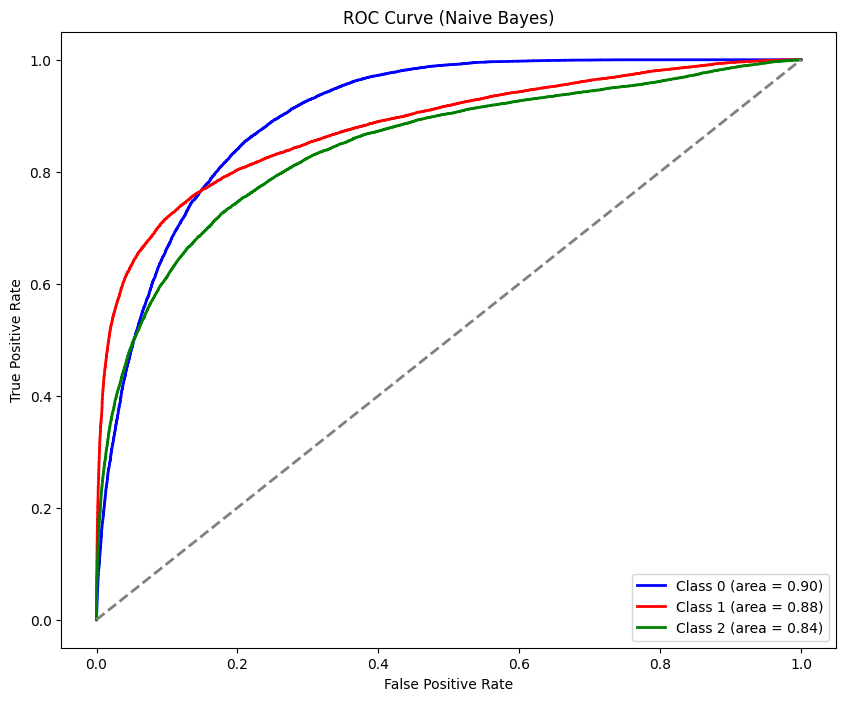

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train Naive Bayes Classifier
nb = GaussianNB()

start_time = time.time()
nb.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"Naive Bayes training completed in {training_time_minutes:.4f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(nb, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (Naive Bayes): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)

# Classification Report
print("Classification Report (Naive Bayes):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Naive Bayes)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Gaussian Naive Bayes/Confusion_Mtrix_Naive_Bayes.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Naive Bayes)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Gaussian Naive Bayes/ROC_Curve_Naive_Bayes.png")
plt.show()

Decision Tree training completed in 1.4009 minutes
Cross-validated Accuracy (Decision Tree): 0.7443
Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.87      0.88      0.88     19749
           1       0.70      0.69      0.70     19373
           2       0.66      0.66      0.66     18358

    accuracy                           0.75     57480
   macro avg       0.74      0.74      0.74     57480
weighted avg       0.75      0.75      0.75     57480



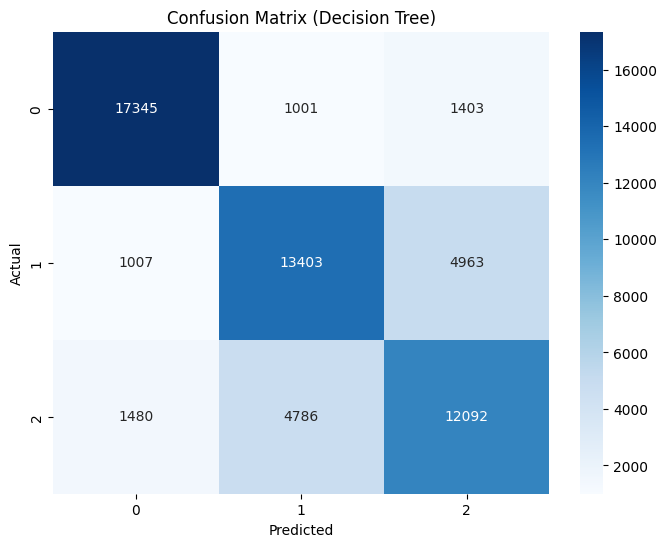

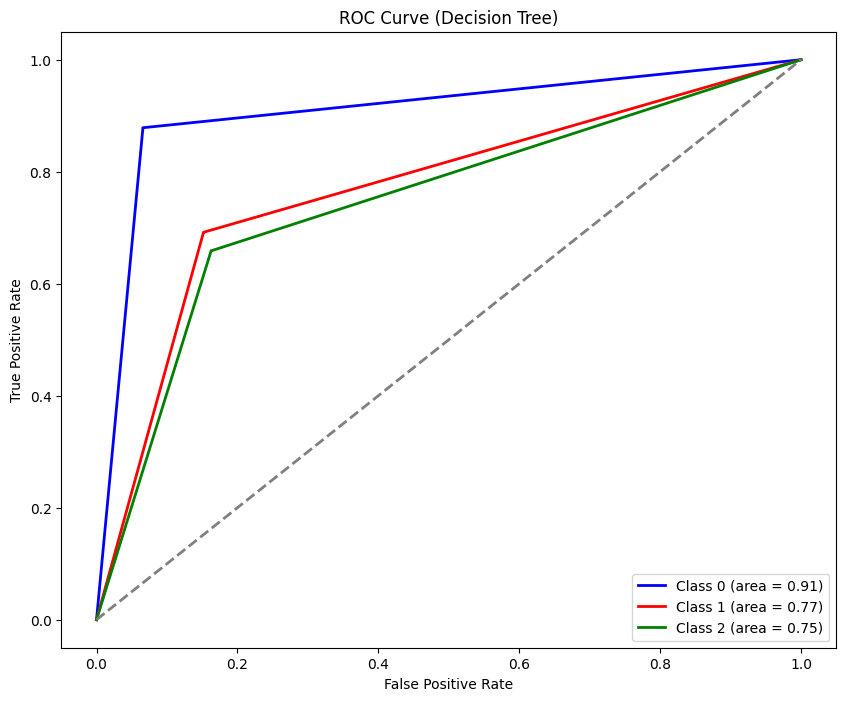

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

start_time = time.time()
dt.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"Decision Tree training completed in {training_time_minutes:.4f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (Decision Tree): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

# Classification Report
print("Classification Report (Decision Tree):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Decision Tree)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Decision Tree/Confusion_Mtrix_DT.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Decision Tree)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Decision Tree/ROC_Curve_DT.png")
plt.show()

Logistic Regression training completed in 0.6590 minutes
Cross-validated Accuracy (Logistic Regression): 0.9086
Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.87      0.85      0.86     19373
           2       0.85      0.86      0.85     18358

    accuracy                           0.91     57480
   macro avg       0.90      0.90      0.90     57480
weighted avg       0.91      0.91      0.91     57480



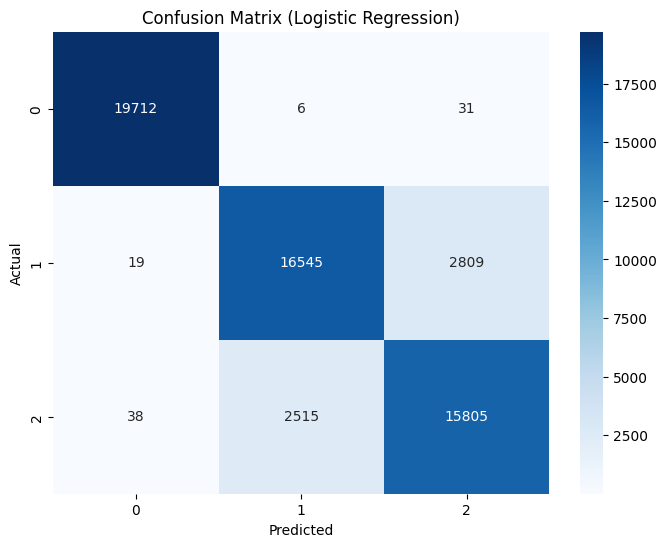

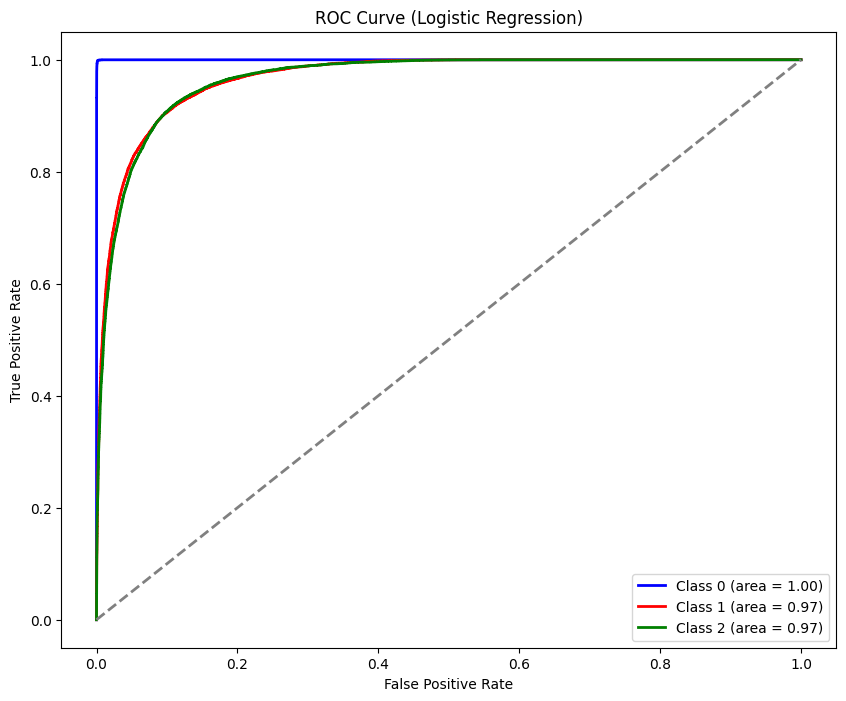

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Train Logistic Regression Classifier
logreg = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
logreg.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"Logistic Regression training completed in {training_time_minutes:.4f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (Logistic Regression): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)

# Classification Report
print("Classification Report (Logistic Regression):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Logistic Regression/Confusion_Mtrix_LR.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/Logistic Regression/ROC_Curve_LR.png")
plt.show()

SVM training completed in 107.5032 minutes
Cross-validated Accuracy (SVM): 0.9217
Classification Report (SVM):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.89      0.87      0.88     19373
           2       0.87      0.89      0.88     18358

    accuracy                           0.92     57480
   macro avg       0.92      0.92      0.92     57480
weighted avg       0.92      0.92      0.92     57480



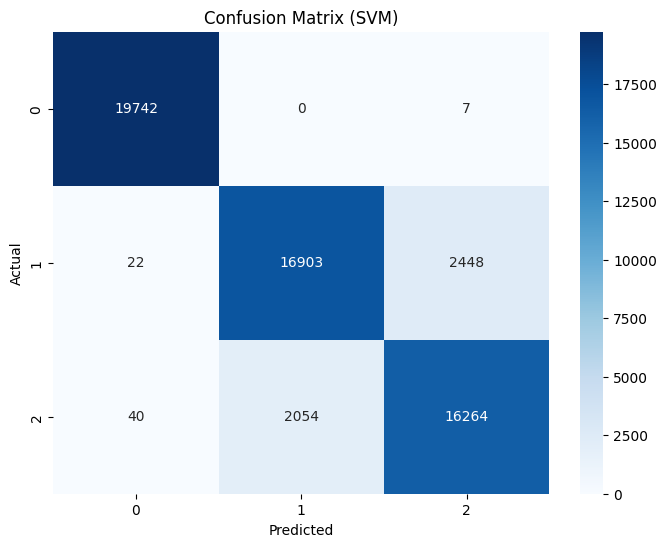

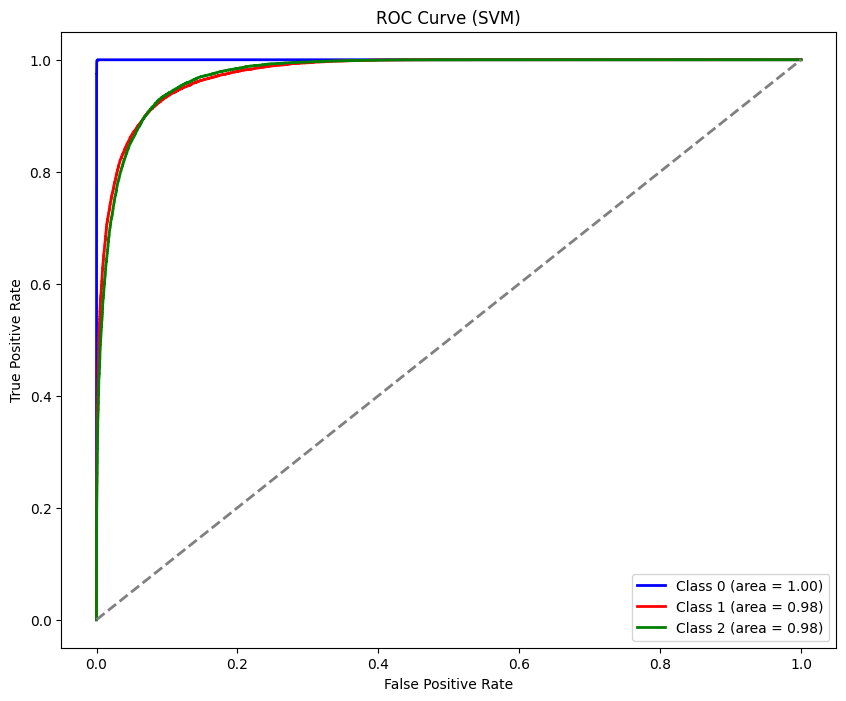

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import time

# Train SVM Classifier
svm = SVC(probability=True, random_state=42)

start_time = time.time()
svm.fit(X_train, y_train)
end_time = time.time()

training_time_minutes = (end_time - start_time) / 60
print(f"SVM training completed in {training_time_minutes:.4f} minutes")

# Cross-Validation Scores
cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy (SVM): {cv_scores.mean():.4f}")

# Predict on Test Set
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)

# Classification Report
print("Classification Report (SVM):\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SVM)')
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/SVM/Confusion_Mtrix_SVM.png")
plt.show()

# ROC Curve and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (SVM)')
plt.legend(loc="lower right")
plt.savefig("E:/Works/10. Mental Health Disorder/Plots/SVM/ROC_Curve_SVM.png")
plt.show()